# 04. CNN 콜백 — 최적 모델 저장하기 (개 vs 고양이)

노트북 03에서 CNN이 깔끔한 데이터(Fashion-MNIST)에서 잘 작동하는 걸 봤다.
이번엔 **진짜 사진** — 개와 고양이 — 으로 넘어간다. 두 가지를 배운다.

1. **콜백(callback)** — 학습 중에 자동으로 개입하는 도구.
   - `EarlyStopping`: 과적합 전에 멈추기 (노트북 01에서 사용)
   - `ModelCheckpoint`: **검증 성능이 가장 좋았던 순간의 모델을 파일로 저장**
2. **데이터 부족의 재확인** — 노트북 02에서 얼굴 12장으로 실패했다.
   이번엔 개/고양이 약 200장. CNN을 써도 데이터가 적으면 어떻게 되는지 본다.

> 이 노트북은 개/고양이 이미지가 Drive에 있어야 실행된다.
> `Colab Notebooks/Dogs_n_Cats/Cats/`, `Colab Notebooks/Dogs_n_Cats/Dogs/` 구조를 가정한다.


## 준비 — Drive 연결과 데이터

개/고양이 이미지는 `Dogs_n_Cats.zip`으로 Drive에 있다. 마운트하고 Colab 로컬에 압축을 푼 뒤,
각 클래스에 몇 장씩 있는지 확인한다.

### 데이터 압축 해제

`Dogs_n_Cats.zip`을 **Colab 로컬(`/content`)에 푼다.** Drive에 직접 풀면 수백 개 파일 쓰기가
느리고, 세션마다 다시 풀면 되므로 로컬이 낫다. zip 안에 `Dogs_n_Cats/` 폴더가 한 겹 더 있어서,
최종 경로는 `/content/dogs_n_cats/Dogs_n_Cats/Cats`, `.../Dogs` 가 된다.


In [14]:
from google.colab import drive
drive.mount('/content/gdrive')

# zip을 Colab 로컬에 압축 해제 (-o 덮어쓰기, -q 조용히, -d 대상)
!unzip -o -q "/content/gdrive/MyDrive/Colab Notebooks/Dogs_n_Cats.zip" -d /content/dogs_n_cats

import os, glob
data_dir = "/content/dogs_n_cats/Dogs_n_Cats"     # zip 안에 폴더가 한 겹 더 있음
cat_files = glob.glob(os.path.join(data_dir, "Cats", "*"))
dog_files = glob.glob(os.path.join(data_dir, "Dogs", "*"))
print("고양이:", len(cat_files), "장 | 개:", len(dog_files), "장")


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
고양이: 101 장 | 개: 101 장


### 이미지 불러오기

- 각 이미지를 **100×100 컬러(RGB)** 로 리사이즈. (얼굴 노트북과 달리 흑백 변환은 하지 않는다 — 개/고양이는 색이 단서다.)
- 고양이 = 0, 개 = 1 로 레이블.
- `Image.open(...).convert('RGB')` : 흑백 이미지가 섞여 있어도 3채널로 통일 (안 하면 shape이 안 맞는다).


x_data: (202, 100, 100, 3) | y_data 분포: (array([0, 1]), array([101, 101]))


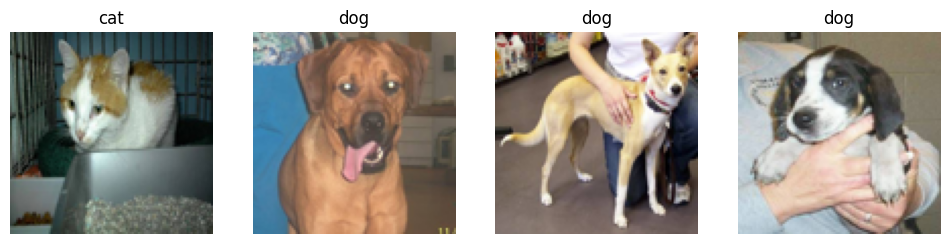

In [15]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

x_list, y_list = [], []
for label, files in [(0, cat_files), (1, dog_files)]:
    for path in files:
        try:
            img = Image.open(path).convert('RGB').resize((100, 100))
            x_list.append(np.array(img))
            y_list.append(label)
        except Exception as e:
            print("건너뜀:", os.path.basename(path), e)

x_data = np.array(x_list)
y_data = np.array(y_list)
print("x_data:", x_data.shape, "| y_data 분포:", np.unique(y_data, return_counts=True))

# 샘플 몇 장 확인 (개/고양이는 저작권 문제 없으니 표시 OK)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, i in zip(axes, np.random.randint(0, len(x_data), 4)):
    ax.imshow(x_data[i])
    ax.set_title("cat" if y_data[i] == 0 else "dog")
    ax.axis('off')
plt.show()


### 전처리와 분할

- `/255` 스케일링
- 원-핫 인코딩
- `stratify`로 클래스 비율 유지하며 8:2 분할


In [16]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

x = x_data / 255
y = to_categorical(y_data)

x_tr, x_te, y_tr, y_te = train_test_split(
    x, y, stratify=y_data, test_size=0.2, random_state=260713
)
print("학습:", x_tr.shape, "| 테스트:", x_te.shape)


학습: (161, 100, 100, 3) | 테스트: (41, 100, 100, 3)


## 콜백 — EarlyStopping + ModelCheckpoint

두 콜백을 함께 쓴다.

### `EarlyStopping` (노트북 01에서 배움)
- `monitor='val_loss'`, `patience=10` : 검증 손실이 10에폭 연속 개선 없으면 멈춤.

### `ModelCheckpoint` (새로 배움) ★
- 학습 도중 **검증 성능이 가장 좋았던 순간의 모델을 파일로 저장**한다.
- `save_best_only=True` : 이전 최고 기록을 갱신할 때만 저장 (매 에폭 저장 X).
- `filepath='CnD.keras'` : 저장할 파일 이름.

**왜 둘 다 필요한가?**
- `restore_best_weights=True`가 있으면 EarlyStopping도 최적 가중치를 메모리에 복원해준다.
- 하지만 `ModelCheckpoint`는 그걸 **디스크 파일로** 남긴다 — 세션이 끊겨도, 나중에 다시 불러 쓸 수 있다.
- 즉 EarlyStopping은 "언제 멈출까 + 메모리 복원", ModelCheckpoint는 "최고 모델을 파일로 백업".

> ⚠️ 원본 수업에서는 `restore_best_weights`가 없었다. 그래서 학습이 끝나면 `model`은
> **망가진 마지막 가중치**를 갖고 있었고, 그것 때문에 `CnD.keras`를 **다시 로드**해야 했다.
> 여기서는 둘 다 제대로 설정해서 그 함정을 피한다.

CNN 구조 (노트북 03과 유사하되 컬러 입력, 필터 수 조정):
```
Input(100,100,3)
  → Conv2D(32, 7×7, same, relu) → MaxPool   # 100 → 50
  → Conv2D(64, 5×5, same, relu) → MaxPool   # 50 → 25
  → Conv2D(32, 5×5, same, relu) → MaxPool   # 25 → 12
  → Flatten → Dense(2, softmax)
```


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

esc = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
chk = ModelCheckpoint(filepath='CnD.keras', monitor='val_loss',
                      save_best_only=True, verbose=1)

model = Sequential()
model.add(Input(shape=(100, 100, 3)))
model.add(Conv2D(32, (7, 7), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(32, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(2, activation='softmax'))
model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

hist = model.fit(x_tr, y_tr,
                 validation_data=(x_te, y_te),
                 epochs=100, callbacks=[esc, chk])


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 32)     │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         9,218 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,450 (454.88 KB)

 Trainable params: 116,450 (454.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.5377 - loss: 0.7167
Epoch 1: val_loss improved from None to 0.69635, saving model to CnD.keras

Epoch 1: finished saving model to CnD.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5031 - loss: 0.7096 - val_accuracy: 0.5122 - val_loss: 0.6963
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5094 - loss: 0.6914
Epoch 2: val_loss improved from 0.69635 to 0.69612, saving model to CnD.keras

Epoch 2: finished saving model to CnD.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5031 - loss: 0.6910 - val_accuracy: 0.4634 - val_loss: 0.6961
Epoch 3/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5728 - loss: 0.6903
Epoch 3: val_loss improved from 0.69612 to 0.69609, saving model to CnD.keras

Epoch 3: finished saving model to CnD.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5714 - loss: 0.6900 - val_accuracy: 0.4390 - val_loss: 0.6961
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - 

### 결과 확인 — train vs val 간격

학습/검증 정확도를 함께 그린다. **두 곡선이 벌어지면 과적합**이다.


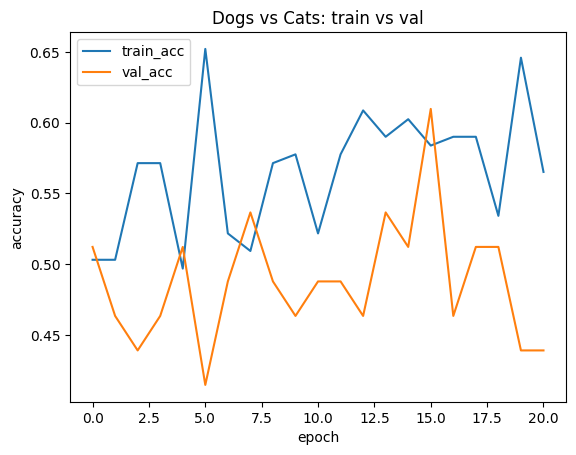

최종 학습 정확도: 0.5652
최고 검증 정확도: 0.6098


In [18]:
plt.plot(hist.history['accuracy'], label='train_acc')
plt.plot(hist.history['val_accuracy'], label='val_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('Dogs vs Cats: train vs val')
plt.show()

print("최종 학습 정확도:", round(hist.history['accuracy'][-1], 4))
print("최고 검증 정확도:", round(max(hist.history['val_accuracy']), 4))


### 결과 — CNN도 데이터가 적으면 무너진다 ★

실행 결과를 정리하면:

**ModelCheckpoint 저장 로그 (셀 위):**
```
Epoch 1: val_loss improved to 0.69758, saving to CnD.keras
Epoch 7: val_loss improved to 0.69729, saving
Epoch 8: val_loss improved to 0.69347, saving
Epoch 9: val_loss improved to 0.69225, saving   ← 마지막 저장 (최저 val_loss)
Epoch 10~19: did not improve
Epoch 19: EarlyStopping 종료 (9 + patience 10)
```

**학습 곡선:**

| | 학습 정확도 | 검증 정확도 | 검증 손실 |
|---|---|---|---|
| 에폭 1 | 0.478 | 0.488 | 0.6976 |
| **에폭 9 (최적)** | 0.665 | 0.512 | **0.6923** ← 최저 |
| 에폭 19 (마지막) | 0.677 | 0.610 | 0.8635 ← 나빠짐 |

읽어야 할 것:

1. **검증 손실이 9에폭 이후 계속 나빠졌다** (0.6923 → 0.8635). 학습 정확도는 0.76까지 오르는데
   검증은 따라오지 못한다. **과적합** — 노트북 01·02에서 본 그 병이 CNN에서도 똑같이 난다.
2. **검증 정확도가 0.5~0.6 언저리.** 개/고양이 2지선다에서 **동전 던지기(0.5)보다 조금 나은 수준**이다.
   CNN을 써도, 위치 정보를 살려도, **202장(학습 161장)으로는 개와 고양이를 제대로 못 배운다.**
3. 원본 수업(train 0.98 / val 0.57)만큼 극단적이진 않지만 **결론은 같다: 데이터가 부족하다.**

> **교훈: 좋은 구조(CNN)도 데이터 부족은 못 이긴다.**
> 노트북 02의 얼굴 12장, 이 노트북의 개/고양이 202장 — 반복되는 메시지다.
> 실전에서 이걸 넘으려면 **데이터 증강(augmentation)**, **전이 학습(transfer learning)** 이 필요하다.

#### 그래도 콜백은 제대로 일했다

실패한 실험이지만 **콜백 자체는 정확히 작동했다:**
- `EarlyStopping`이 9에폭(최적) + patience 10 = 19에폭에서 멈춰 무의미한 학습을 막았다.
- `ModelCheckpoint`가 9에폭의 최적 모델을 `CnD.keras`로 저장했다.
- `restore_best_weights=True` 덕에 메모리의 `model`도 9에폭으로 복원됐다.

다음 셀에서 저장된 파일을 실제로 불러온다.

### 저장된 모델 다시 불러오기 — `ModelCheckpoint`의 결실

`ModelCheckpoint`가 남긴 `CnD.keras` 파일을 불러온다.
이게 콜백의 진짜 가치다 — **세션이 끊겨도 최적 시점의 모델이 파일로 남아 있다.**

> 원본 수업에서는 `restore_best_weights`가 없어서, 학습 직후의 `model`이 망가진 마지막 가중치였고
> **반드시 이 재로딩을 거쳐야** 최적 모델을 쓸 수 있었다. 여기서는 메모리와 파일이 이미 일치하지만,
> "파일로 백업된다"는 점은 그대로 유효하다.

In [19]:
from tensorflow.keras.models import load_model
import os

print("CnD.keras 존재:", os.path.exists("CnD.keras"),
      "| 크기:", os.path.getsize("CnD.keras"), "bytes")

best_model = load_model("CnD.keras")
loss, acc = best_model.evaluate(x_te, y_te, verbose=0)
print(f"불러온 최적 모델 — 검증 정확도: {acc:.4f}, 검증 손실: {loss:.4f}")


CnD.keras 존재: True | 크기: 1437234 bytes
불러온 최적 모델 — 검증 정확도: 0.4878, 검증 손실: 0.6949


### 마무리

불러온 최적 모델의 검증 정확도는 **0.4878** — 학습 로그의 최고치(0.61)보다 낮다.
`ModelCheckpoint`는 **`val_loss`가 가장 낮은** 9에폭을 저장했는데, 그 시점의 *정확도*는 0.49였기 때문이다.
(검증 세트가 41장뿐이라 정확도가 에폭마다 크게 출렁인다.) 어느 쪽으로 봐도 결론은 같다 —
**동전 던지기 수준. 데이터가 부족하다.**

---

## 정리

| 개념 | 핵심 |
|---|---|
| **ModelCheckpoint** | 검증 성능 최고 시점의 모델을 **파일로** 저장. `save_best_only=True` |
| **EarlyStopping + Checkpoint** | 전자는 "언제 멈출까 + 메모리 복원", 후자는 "최고 모델을 디스크에 백업" |
| **load_model** | 저장한 `.keras`를 불러와 재사용. 세션이 끊겨도 최적 모델이 남는다 |
| **CNN ≠ 만능** | 좋은 구조도 **데이터 부족**은 못 이긴다 (202장 → val 0.5) |

**다음 노트북(05)** 에서는 지금까지의 분류(정답 맞히기)를 벗어나,
**정답 없이 스스로 학습하는 AutoEncoder**를 본다. 이미지를 압축했다가 복원하며,
Dense 디코더 vs Conv 디코더를 비교하고, 2차원으로 압축한 잠재공간을 눈으로 그려본다.